# Find edge projectors initial test
Created 10/08/2026

Objectives:
* Try and find edge projectors for these states. Can we find the resulting defect operators too?

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [4]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import cycle

# Load data

In [8]:
L=20
basis = spin_basis_1d(L)

In [9]:
DATA_DIR = r"../../data/quspin_transverse_cluster_20_site"

In [10]:
energies = [
    np.load(rf'{DATA_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

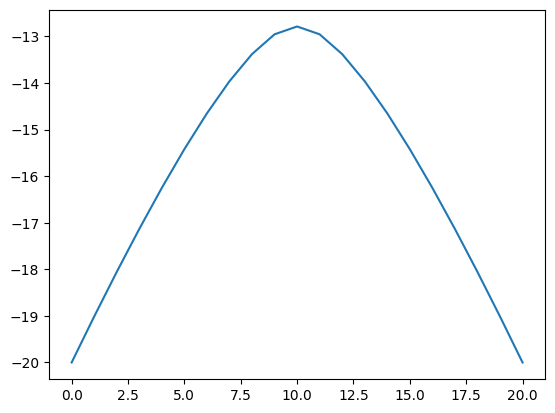

In [11]:
plt.plot(energies)

In [12]:
energies[0], energies[-1]

(array([-20.]), array([-20.]))

In [13]:
groundstates = [
    np.load(rf'{DATA_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [14]:
parameters = np.linspace(0, 1, 21)

In [15]:
parameters

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [16]:
inds = [f'k{i}' for i in range(L)]

qt_groundstates = [
    qtn.Tensor(
        psi[::-1].reshape((2,)*L),
        inds=inds
    )
    for psi in groundstates
]

# Definitions

In [17]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [18]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])

In [19]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [20]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [21]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Optimisation functions

In [22]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

# Test

In [23]:
left_rho_sites = list(range(8, 10))
right_rho_sites = list(range(10, 12))

rho_sites = left_rho_sites + right_rho_sites

In [24]:
psi = qt_groundstates[-1]
rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

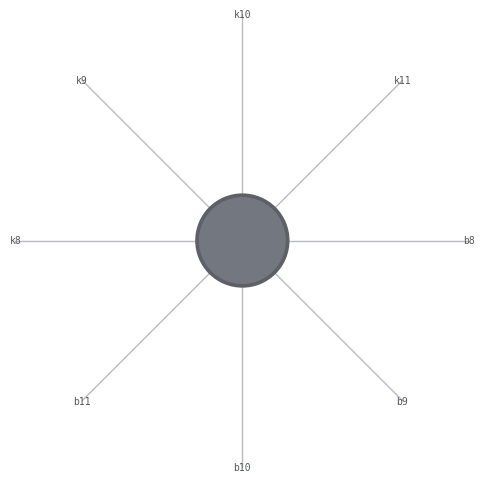

In [25]:
rho.draw()

In [26]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [27]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [28]:
(
    rho
    & left_state
    & right_state
    & left_state.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})
    & right_state.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})
).contract()

(1.2730930133548584+0j)

In [29]:
help(rho.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [30]:
def maximize_projector_states(rho, left_rho_sites, right_rho_sites,
                              num_iters=20):
    scores = list()

    left_k_inds = [f'k{i}' for i in left_rho_sites]
    left_b_inds = [f'b{i}' for i in left_rho_sites]
    right_k_inds = [f'k{i}' for i in right_rho_sites]
    right_b_inds = [f'b{i}' for i in right_rho_sites]

    fused_rho = rho.fuse({
        'kl': left_k_inds,
        'kr': right_k_inds,
        'bl': left_b_inds,
        'br': right_b_inds
    })

    left_state = qtn.Tensor(
        data=random_uniform_complex((2**len(left_rho_sites),)),
        inds=['kl',]
    )
    
    right_state = qtn.Tensor(
        data=random_uniform_complex((2**len(right_rho_sites),)),
        inds=['kr',]
    )

    for i in range(num_iters):
        right_matrix = (
            fused_rho
            & left_state.conj()
            & left_state.reindex({'kl': 'bl'})
        ).contract()
        data = (
            right_matrix
            .transpose('kr', 'br')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        right_state = qtn.Tensor(
            data=state_data,
            inds=['kr',]
        )
        scores.append(score)

        left_matrix = (
            fused_rho
            & right_state.conj()
            & right_state.reindex({'kr': 'br'})
        ).contract()
        data = (
            left_matrix
            .transpose('kl', 'bl')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        left_state = qtn.Tensor(
            data=state_data,
            inds=['kl',]
        )
        scores.append(score)

    left_state.unfuse(
        {'kl': left_k_inds},
        shape_map={'kl': (2,)*len(left_k_inds)},
        inplace=True
    )
    right_state.unfuse(
        {'kr': right_k_inds},
        shape_map={'kr': (2,)*len(right_k_inds)},
        inplace=True
    )

    return scores, (left_state, right_state)

In [31]:
test_out = maximize_projector_states(
    rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [32]:
test_scores = test_out[0]

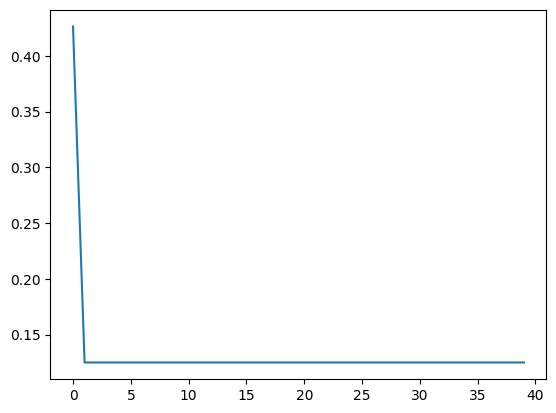

In [33]:
plt.plot(test_scores)

In [34]:
test_scores

[0.4262387824959105,
 0.12500000000000006,
 0.12500000000000003,
 0.1250000000000001,
 0.125,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000006,
 0.1250000000000001,
 0.125,
 0.125,
 0.12499999999999999,
 0.12499999999999997,
 0.12500000000000008,
 0.125,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000006,
 0.125,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000003,
 0.12499999999999996,
 0.12500000000000006,
 0.12499999999999996,
 0.125,
 0.12499999999999997,
 0.125,
 0.125,
 0.12499999999999997,
 0.12499999999999997,
 0.12500000000000006,
 0.12499999999999999,
 0.125,
 0.125,
 0.12500000000000003,
 0.12499999999999997,
 0.12500000000000006]

In [35]:
left_rho_sites = list(range(4, 6))
right_rho_sites = list(range(6, 8))

rho_sites = left_rho_sites + right_rho_sites

In [36]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [37]:
help(left_rho.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [38]:
left_test_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [39]:
left_rho_sites = list(range(12, 14))
right_rho_sites = list(range(14, 16))

rho_sites = left_rho_sites + right_rho_sites

In [40]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [41]:
right_test_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [42]:
right_test_out[0]

[0.2756692522618588,
 0.12500000000000008,
 0.1250000000000002,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000003,
 0.125,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000003,
 0.1250000000000001,
 0.12500000000000008,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000003,
 0.1250000000000001,
 0.12500000000000006,
 0.1250000000000002,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000014,
 0.12500000000000014,
 0.12500000000000008,
 0.12500000000000006,
 0.12500000000000014,
 0.1250000000000001,
 0.12500000000000003,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000003,
 0.125]

In [43]:
left_test_out[0]

[0.13158757887464048,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.12499999999999997,
 0.12500000000000008,
 0.12500000000000006,
 0.125,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000006,
 0.12500000000000006,
 0.12499999999999997,
 0.12500000000000006,
 0.12500000000000017,
 0.125,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999999,
 0.12500000000000006,
 0.1250000000000001,
 0.12499999999999997,
 0.12500000000000003,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000008,
 0.12500000000000003,
 0.12499999999999994,
 0.12500000000000003,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000017,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000006,
 0.12500000000000003]

In [44]:
left_test_out[1]

(Tensor(shape=(2, 2), inds=('k4', 'k5'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([])))

In [45]:
left_proj_state = left_test_out[1][1]
right_proj_state = right_test_out[1][0]

In [46]:
np.round(left_proj_state.data, 3)

array([[ 0.616-0.065j,  0.316+0.011j],
       [ 0.64 +0.j   , -0.323-0.046j]])

In [47]:
np.round(right_proj_state.data, 3)

array([[ 0.688+0.j   , -0.302+0.277j],
       [ 0.5  +0.125j,  0.27 -0.147j]])

In [48]:
np.round(left_test_out[1][0].data, 3)

array([[-0.31 +0.572j, -0.025-0.026j],
       [ 0.757+0.j   ,  0.013-0.04j ]])

In [49]:
np.round(right_test_out[1][1].data, 3)

array([[ 0.262-0.328j,  0.   -0.j   ],
       [ 0.908+0.j   , -0.   +0.j   ]])

In [50]:
psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19'), tags=oset([]))

In [51]:
left_proj_state

Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([]))

In [52]:
right_proj_state

Tensor(shape=(2, 2), inds=('k12', 'k13'), tags=oset([]))

In [53]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k7': 'b7', 'k12': 'b12', 'k13': 'b13'})
    & left_proj_state.conj().reindex({'k6': 'b6', 'k7': 'b7'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k12': 'b12', 'k13': 'b13'})
    & right_proj_state
)

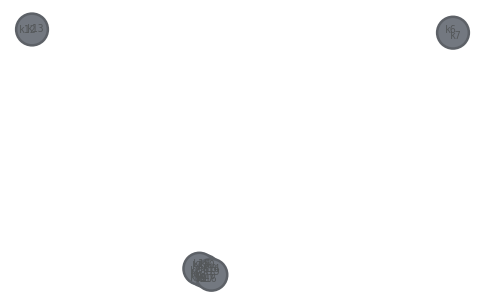

In [54]:
proj_psi.draw()

In [55]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [56]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [57]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [58]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [59]:
norm

(0.9999999999999969+0j)

Check Schmidt decomposition

In [60]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [61]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [62]:
schmidt_decomp.tensors[1].data

array([1.])

In [63]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    psi,
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [64]:
schmidt_decomp.tensors[1].data

array([0.5, 0.5, 0.5, 0.5])

Nice, clean cut.

In [65]:
schmidt_decomp

TensorNetwork(tensors=3, indices=21)

In [66]:
cut_psi = schmidt_decomp.tensors[0]

In [67]:
cut_psi = cut_psi.isel({'vLV':0})

In [68]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [69]:
sites = list(range(6, 14))

In [70]:
edm = generate_edm(cut_psi, sites, symmetry_actions[1], 3)

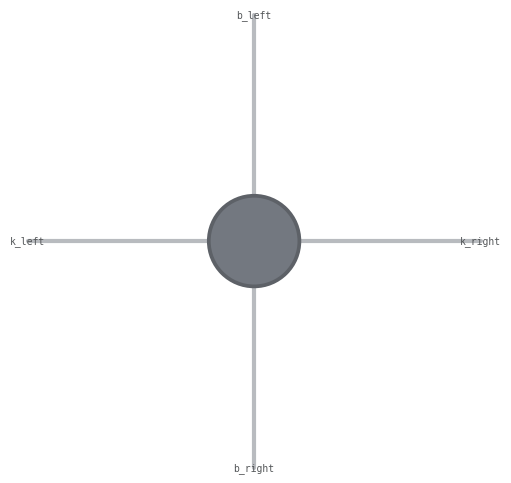

In [71]:
edm.draw()

In [72]:
edm.ind_size('k_left')

8

In [73]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [74]:
defect_ops_out[1]

[0.6677511723153172,
 0.7541867974879931,
 0.7648960378725601,
 0.7821909594963146,
 0.8079204541846426,
 0.8419074870136489,
 0.8804221034244811,
 0.9171835573493964,
 0.9469395205368126,
 0.9679580308046253,
 0.981408957721451,
 0.9894780908196125,
 0.9941315497848516,
 0.9967542072046199,
 0.9982131696823707,
 0.9990188903999907,
 0.9994620650789525,
 0.9997052864071964,
 0.9998386075849409,
 0.9999116384469736,
 0.9999516287518411,
 0.9999735222888589,
 0.9999855070524529,
 0.9999920672499806,
 0.9999956580405439,
 0.9999976234607422,
 0.9999986992234232,
 0.9999992880334424,
 0.9999996103129013,
 0.9999997867091563,
 0.9999998832576958,
 0.9999999361024459,
 0.9999999650264139,
 0.9999999808576134,
 0.999999989522637,
 0.9999999942653371,
 0.9999999968611991,
 0.9999999982820139,
 0.9999999990596801,
 0.9999999994853267]

Needed 3 site defect operators, for some reason...

In [75]:
edms = [
    generate_edm(cut_psi, sites, s, 3)
    for s in symmetry_actions[1:]
]

In [76]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

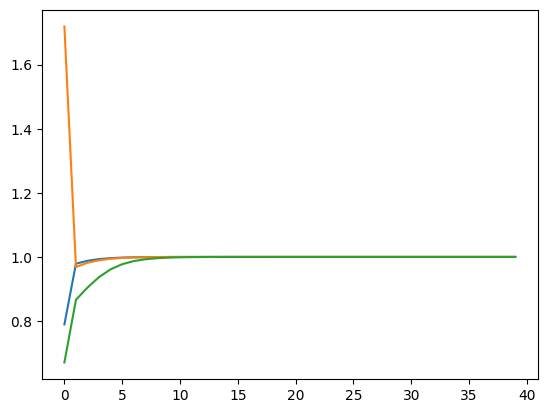

In [77]:
for l in defect_ops_results:
    plt.plot(l[1])

In [78]:
[l[1][-1] for l in defect_ops_results]

[0.9999999999973807, 0.9999999999959298, 0.9999999999685311]

Looks good! Now calculate the invariants.

## SPT extraction functions

In [79]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [80]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [81]:
e, a, b, c = symmetry_labels

In [82]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [83]:
defect_ops_results[0][0][1]

Tensor(shape=(8, 8), inds=('b_right', 'k_right'), tags=oset([]))

In [84]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [85]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [86]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [87]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [88]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [89]:
left_defect_sites = [6, 7, 8]
right_defect_sites = [11, 12, 13]

In [90]:
left_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(8, 8), inds=('k_right', 'b_right'), tags=oset([]))

In [91]:
left_rdm

Tensor(shape=(8, 8), inds=('k_left', 'b_left'), tags=oset([]))

In [92]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [93]:
left_rdm

Tensor(shape=(8, 8), inds=('k_left', 'b_left'), tags=oset([]))

In [94]:
right_rdm

Tensor(shape=(8, 8), inds=('k_right', 'b_right'), tags=oset([]))

In [95]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [96]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [97]:
left_phases

array([-0.72640205-0.00536512j,  0.59935977-0.54062077j,
        0.5523753 -0.17240665j, -0.38670963+0.87118649j,
        0.62630947-0.53592499j, -0.16973754+0.70604856j])

In [98]:
left_phases[::2]/left_phases[1::2]

array([-0.6638123 -0.60770817j, -0.40044369-0.4562971j ,
       -0.9191791 -0.6660877j ])

Invariants are totally wrong, shoot.

## Manual projectors, $\ket{0}\bra{0}_Z$

In [99]:
left_proj_state = qtn.Tensor(data=[1,0], inds=['k6'])
right_proj_state = qtn.Tensor(data=[1,0], inds=['k13'])

In [100]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k13': 'b13'})
    & left_proj_state.conj().reindex({'k6': 'b6'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k13': 'b13'})
    & right_proj_state
)

In [101]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [102]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [103]:
norm

(0.2500000000000195+0j)

In [104]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [105]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [106]:
norm

(1.0000000000000522+0j)

Check Schmidt decomposition

In [107]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [108]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [109]:
schmidt_decomp.tensors[1].data

array([1.])

In [110]:
cut_psi = schmidt_decomp.tensors[0]

In [111]:
cut_psi = cut_psi.isel({'vLV':0})

In [112]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [113]:
sites = list(range(6, 14))

In [114]:
edm = generate_edm(cut_psi, sites, symmetry_actions[1], 2)

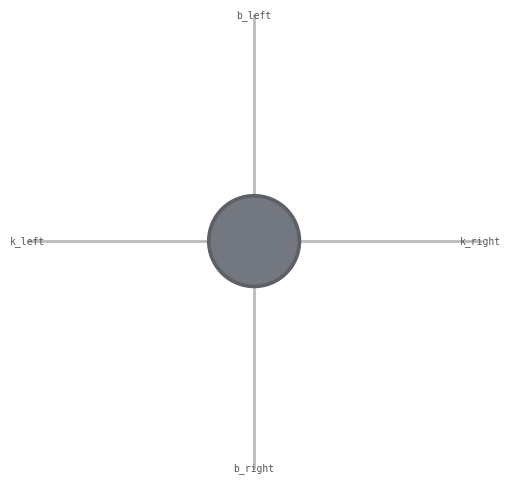

In [115]:
edm.draw()

In [116]:
edms = [
    generate_edm(cut_psi, sites, s, 2)
    for s in symmetry_actions[1:]
]

In [117]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

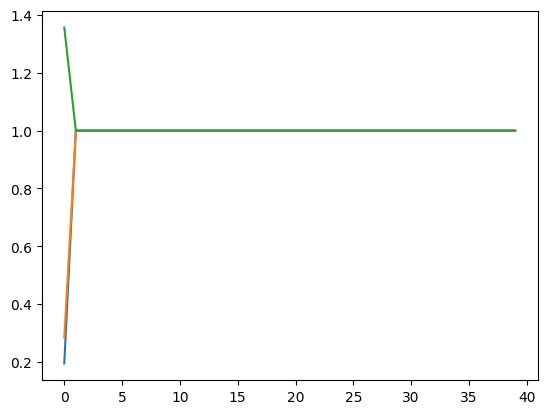

In [118]:
for l in defect_ops_results:
    plt.plot(l[1])

In [119]:
left_defect_sites = [6, 7]
right_defect_sites = [12, 13]

In [120]:
left_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset([]))

In [121]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [122]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [123]:
left_phases

array([-0.88734065+0.46111448j, -0.98435615+0.17619018j,
       -0.99219501+0.12469588j, -0.98435615-0.17619018j,
       -0.39031327+0.7510951j ,  0.4906479 -0.81246536j])

In [124]:
left_phases[::2]/left_phases[1::2]

array([ 0.95470307-0.29756017j,  0.95470307-0.29756017j,
       -0.89000189+0.05706618j])

In [125]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [126]:
right_phases

array([ 7.95891381e-01-5.95043529e-01j,  8.87340652e-01+4.61114484e-01j,
       -1.25355408e-16+6.30139594e-17j,  4.85077468e-02+1.42462153e-01j,
        9.08143408e-01+4.03479172e-01j,  3.14532339e-02+9.99505225e-01j])

In [127]:
right_phases[::2]/right_phases[1::2]

array([4.31843587e-01-8.95003356e-01j, 1.27884858e-16+9.23465018e-16j,
       4.31843587e-01-8.95003356e-01j])

In [128]:
np.round(
    left_unitaries[0]
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ) 
    .transpose('k1', 'b1', 'k2', 'b2')
    .data,
    3
)

array([[[[ 0.955-0.298j,  0.   -0.j   ],
         [-0.   +0.j   ,  0.955-0.298j]],

        [[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  0.   -0.j   ]]],


       [[[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  0.   -0.j   ]],

        [[ 1.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  1.   -0.j   ]]]])

In [129]:
def split_defect_op(defect_op, left_right):
    unfused_defect_op = (
        defect_op
        .unfuse(
            {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
            shape_map = {f'k_{left_right}': (2,2), f'b_{left_right}': (2,2)}
        )
    )

    schmidt_decomp = qtn.tensor_core.tensor_split(
        unfused_defect_op,
        left_inds=['k1', 'k2'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='v'
    )

    return schmidt_decomp

In [130]:
U, s, V = split_defect_op(
    left_unitaries[0],
    'left'
)

In [131]:
s

Tensor(shape=(4,), inds=('v',), tags=oset([]))

Oh, it's entangled.

In [132]:
qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

TensorNetwork(tensors=3, indices=21)

In [133]:
np.round(left_unitaries[1].transpose('k_left', 'b_left').data, 3)

array([[ 0.   -0.j   ,  0.   -0.j   ,  0.532-0.846j, -0.   +0.j   ],
       [ 0.   -0.j   ,  0.   +0.j   , -0.   +0.j   , -0.532+0.846j],
       [ 1.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.   -0.j   , -0.433+0.901j, -0.   -0.j   ,  0.   +0.j   ]])

In [134]:
np.round(left_unitaries[2].transpose('k_left', 'b_left').data, 3)

array([[ 0.   -0.j   ,  0.   +0.j   , -0.673+0.739j,  0.   +0.j   ],
       [ 0.   -0.j   ,  0.   -0.j   , -0.   -0.j   ,  0.673-0.739j],
       [ 1.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.   -0.j   , -0.802+0.598j, -0.   -0.j   ,  0.   +0.j   ]])

Ok, calculate EDM.

In [135]:
edms[0]

Tensor(shape=(4, 4, 4, 4), inds=('k_left', 'b_left', 'k_right', 'b_right'), tags=oset([]))

In [136]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edms[0],
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='v'
)

In [137]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset([]))

In [138]:
schmidt_decomp.tensors[0]

Tensor(shape=(4, 4, 1), inds=('k_left', 'b_left', 'v'), tags=oset([]), left_inds=('k_left', 'b_left'))

In [139]:
np.round(
    schmidt_decomp
    .tensors[0]
    .isel({'v': 0})
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ).data,
    3
)

array([[[[ 0.707+0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]],

        [[-0.   +0.j,  0.707+0.j],
         [ 0.   +0.j,  0.   +0.j]]],


       [[[ 0.   +0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]],

        [[ 0.   +0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]]]])

## Full EDM without projectors

In [140]:
sites

[6, 7, 8, 9, 10, 11, 12, 13]

In [141]:
edms = [
    generate_edm(psi, sites, s, 2)
    for s in symmetry_actions[1:]
]

Nice.

In [142]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

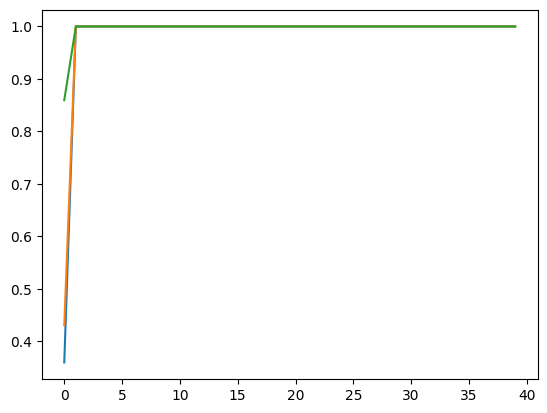

In [143]:
for l in defect_ops_results:
    plt.plot(l[1])

In [144]:
[l[1][-1] for l in defect_ops_results]

[0.9999999999999993, 0.9999999999999996, 0.9999999999999997]

In [145]:
sites

[6, 7, 8, 9, 10, 11, 12, 13]

In [146]:
left_defect_sites = [6, 7]
right_defect_sites = [12, 13]

In [147]:
left_rdm = (
    psi
    & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    psi
    & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset([]))

In [148]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [149]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [150]:
left_phases

array([-0.33155321-0.94343652j,  0.33155321+0.94343652j,
       -0.69419885-0.71978327j,  0.69419885+0.71978327j,
        0.48534844+0.87432082j, -0.48534844-0.87432082j])

In [151]:
left_phases[::2]/left_phases[1::2]

array([-1.+5.23712474e-17j, -1.+7.99119959e-17j, -1.-0.00000000e+00j])

So it does work in the full case...! What am I missing?

In [152]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edms[0],
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='v'
)

In [153]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset([]))

In [154]:
np.round(
    schmidt_decomp
    .tensors[0]
    .isel({'v': 0})
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ).data,
    3
)

array([[[[-0.42+0.272j, -0.  +0.j   ],
         [ 0.  +0.j   , -0.  +0.j   ]],

        [[-0.  -0.j   , -0.42+0.272j],
         [ 0.  -0.j   , -0.  -0.j   ]]],


       [[[ 0.  +0.j   , -0.  +0.j   ],
         [ 0.42-0.272j, -0.  -0.j   ]],

        [[ 0.  -0.j   , -0.  -0.j   ],
         [ 0.  -0.j   ,  0.42-0.272j]]]])

## Larger support defect operators

In [155]:
left_rho_sites = list(range(2, 4))
right_rho_sites = list(range(4, 6))

rho_sites = left_rho_sites + right_rho_sites

In [156]:
psi = qt_groundstates[-1]
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [157]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [158]:
left_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [159]:
left_out[0]

[0.3566163000296904,
 0.12500000000000006,
 0.12500000000000003,
 0.12499999999999999,
 0.12500000000000006,
 0.12500000000000003,
 0.125,
 0.12499999999999996,
 0.12499999999999992,
 0.12500000000000006,
 0.12500000000000006,
 0.125,
 0.12500000000000006,
 0.12500000000000006,
 0.125,
 0.125,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000008,
 0.125,
 0.12499999999999996,
 0.12499999999999997,
 0.12499999999999997,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000006,
 0.12499999999999994,
 0.125,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000003,
 0.125,
 0.125,
 0.12499999999999997,
 0.12499999999999993,
 0.12499999999999996,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999999]

In [160]:
left_rho_sites = list(range(14, 16))
right_rho_sites = list(range(16, 18))

rho_sites = left_rho_sites + right_rho_sites

In [161]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [162]:
right_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [163]:
right_out[0]

[0.15025012973921198,
 0.12500000000000006,
 0.12500000000000003,
 0.1250000000000001,
 0.1250000000000002,
 0.125,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000003,
 0.1250000000000001,
 0.1250000000000002,
 0.12500000000000003,
 0.12500000000000008,
 0.12499999999999999,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000006,
 0.12500000000000017,
 0.12500000000000006,
 0.12500000000000022,
 0.12500000000000006,
 0.1250000000000001,
 0.125,
 0.1250000000000001,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999997,
 0.12500000000000008,
 0.12500000000000006]

In [164]:
left_proj_state = left_out[1][1]
right_proj_state = right_out[1][0]

In [165]:
proj_psi = (
    psi.reindex({'k4': 'b4', 'k5': 'b5', 'k14': 'b14', 'k15': 'b15'})
    & left_proj_state.conj().reindex({'k4': 'b4', 'k5': 'b5'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k14': 'b14', 'k15': 'b15'})
    & right_proj_state
)

In [166]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [167]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [168]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [169]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [170]:
norm

(0.9999999999999962+0j)

Check Schmidt decomposition

In [171]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [172]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [173]:
schmidt_decomp.tensors[1].data

array([1.])

## Use external projectors instead.

In [192]:
left_rho_sites = list(range(4, 6))
right_rho_sites = list(range(6, 8))

rho_sites = left_rho_sites + right_rho_sites

In [193]:
psi = qt_groundstates[-1]
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [194]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [195]:
left_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [196]:
left_out[0]

[0.3157568908823527,
 0.12500000000000006,
 0.125,
 0.12499999999999993,
 0.125,
 0.12499999999999999,
 0.125,
 0.12499999999999997,
 0.12500000000000006,
 0.12500000000000008,
 0.12499999999999997,
 0.12500000000000003,
 0.125,
 0.125,
 0.125,
 0.12500000000000006,
 0.12500000000000008,
 0.1250000000000001,
 0.12500000000000003,
 0.1250000000000001,
 0.125,
 0.12499999999999996,
 0.125,
 0.12500000000000006,
 0.12499999999999996,
 0.125,
 0.12499999999999999,
 0.12500000000000014,
 0.125,
 0.12500000000000008,
 0.12500000000000006,
 0.12499999999999992,
 0.12500000000000008,
 0.12500000000000003,
 0.1250000000000001,
 0.125,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000003]

In [197]:
left_rho_sites = list(range(12, 14))
right_rho_sites = list(range(14, 16))

rho_sites = left_rho_sites + right_rho_sites

In [198]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [199]:
right_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [200]:
right_out[0]

[0.3176351308940314,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.125,
 0.125,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000014,
 0.12500000000000014,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000008,
 0.12500000000000008,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000003,
 0.12500000000000008,
 0.1250000000000001,
 0.1250000000000001,
 0.12500000000000014,
 0.12499999999999997,
 0.12500000000000006,
 0.12500000000000003,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000006,
 0.12500000000000008,
 0.12500000000000003,
 0.12500000000000006,
 0.1250000000000001,
 0.12500000000000006,
 0.12500000000000003]

In [201]:
left_proj_state = left_out[1][0]
right_proj_state = right_out[1][1]

In [202]:
proj_psi = (
    psi.reindex({'k4': 'b4', 'k5': 'b5', 'k14': 'b14', 'k15': 'b15'})
    & left_proj_state.conj().reindex({'k4': 'b4', 'k5': 'b5'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k14': 'b14', 'k15': 'b15'})
    & right_proj_state
)

In [203]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [204]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [205]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [206]:
norm

(1.0000000000000027-2.7755575615628914e-17j)

Check Schmidt decomposition

In [207]:
proj_psi

TensorNetwork(tensors=5, indices=24)

In [208]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [209]:
schmidt_decomp.tensors[1].data

array([0.65975396, 0.65975396, 0.65975396, 0.65975396])

# Conclusions
Things aren't working out the way we want. Our projection optimizer is making some assumptions, and we need to calculate multiple projectors simultaneously.
(Fun!)

To explore larger system sizes, should just work with circuit prepared cluster states directly.

# Old code

## Single site projectors test

In [217]:
left_rho_sites = [4]
right_rho_sites = [5]

rho_sites = left_rho_sites + right_rho_sites

In [218]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [220]:
left_single_site_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

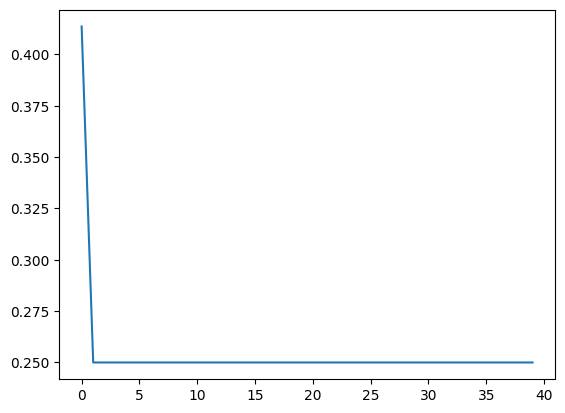

In [221]:
plt.plot(single_site_out[0])

In [222]:
left_rho_sites = [14]
right_rho_sites = [15]

rho_sites = left_rho_sites + right_rho_sites

In [223]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [224]:
right_single_site_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

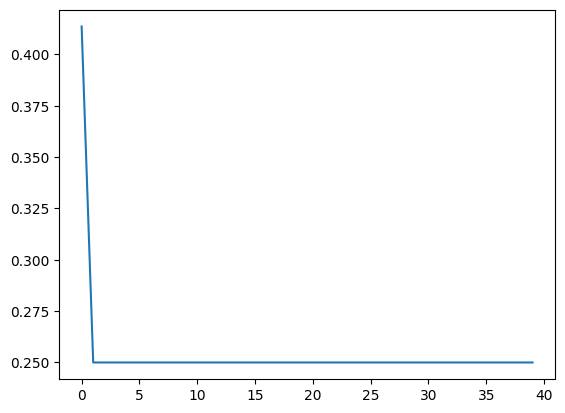

In [225]:
plt.plot(single_site_out[0])

In [226]:
left_single_site_out[1][0]

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

In [227]:
left_single_site_out[1][1]

Tensor(shape=(2,), inds=('k5',), tags=oset([]))

In [228]:
right_single_site_out[1][0]

Tensor(shape=(2,), inds=('k14',), tags=oset([]))

In [229]:
right_single_site_out[1][1]

Tensor(shape=(2,), inds=('k15',), tags=oset([]))

In [172]:
np.round(rho.data, 3)

array([[[[ 0.25+0.j, -0.  -0.j],
         [ 0.  -0.j, -0.  -0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [ 0.  -0.j, -0.  -0.j]]],


       [[[ 0.  +0.j,  0.  +0.j],
         [ 0.25+0.j, -0.  +0.j]],

        [[-0.  +0.j, -0.  +0.j],
         [-0.  -0.j,  0.25+0.j]]]])

In [176]:
np.round(rho.fuse({'k': ['k10', 'k11'], 'b': ['b10', 'b11']}).data, 3)

array([[ 0.25+0.j, -0.  -0.j,  0.  -0.j, -0.  -0.j],
       [-0.  +0.j,  0.25+0.j,  0.  -0.j, -0.  -0.j],
       [ 0.  +0.j,  0.  +0.j,  0.25+0.j, -0.  +0.j],
       [-0.  +0.j, -0.  +0.j, -0.  -0.j,  0.25+0.j]])

In [233]:
left_proj_state = left_single_site_out[1][1]
right_proj_state = right_single_site_out[1][0]

In [234]:
left_proj_state

Tensor(shape=(2,), inds=('k5',), tags=oset([]))

In [235]:
right_proj_state

Tensor(shape=(2,), inds=('k14',), tags=oset([]))

In [236]:
proj_psi = (
    psi.reindex({'k5': 'b5', 'k14': 'b14'})
    & left_proj_state.conj().reindex({'k5': 'b5'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k14': 'b14'})
    & right_proj_state
)

In [237]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [238]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [239]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [240]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [241]:
norm

(1.0000000000001426+0j)

In [242]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [243]:
schmidt_decomp.tensors[1].data

array([0.93267615, 0.36071484])

In [245]:
np.sum(np.power(schmidt_decomp.tensors[1].data, 2))

1.000000000000068

So kinda entangled. Two site seems like the way to go, unfortunately.